In [2]:
import config
from azure.cognitiveservices.vision.computervision import ComputerVisionClient
from azure.cognitiveservices.vision.computervision.models import OperationStatusCodes
from msrest.authentication import CognitiveServicesCredentials

def computer_vision_client():
    computervision_client = ComputerVisionClient(
    endpoint=config.VISION_ENDPOINT,
    credentials=CognitiveServicesCredentials(config.VISION_KEY))
    return computervision_client


In [14]:
from azure.cognitiveservices.vision.computervision.models import VisualFeatureTypes

#checking if one file has bike

def has_bike1(computervision_client, img_path):
    results = {}
    try:
        with open(img_path, "rb") as image_file:
            analysis = computervision_client.analyze_image_in_stream(
                        image_file,
                        visual_features=[VisualFeatureTypes.objects, VisualFeatureTypes.tags]
                    )
            
            has_bike = False
            
            if analysis.objects:
                for obj in analysis.objects:
                    if obj.object_property and 'bicycle' in obj.object_property.lower():
                        has_bike = True
                        break
            
            if not has_bike and analysis.tags:
                for tag in analysis.tags:
                    if 'bicycle' in tag.name.lower() and tag.confidence > 0.5:
                        has_bike = True
                        break
            
            results[img_path] = {
                        'has_bike': has_bike,
                        'objects': analysis.objects if analysis.objects else [],
                        'tags': analysis.tags if analysis.tags else []
                    }
            print(f"Processed {img_path}: {'Contains bike' if has_bike else 'No bike'}")
    except Exception as e:
        print(f"Error analyzing image: {e}")
    
    return has_bike, results
    

has_bike1(computer_vision_client(), "data/test_images/bike02.jpg")
                    

Processed bike02.jpg: Contains bike


(True,
 {'bike02.jpg': {'has_bike': True,
   'objects': [<azure.cognitiveservices.vision.computervision.models._models_py3.DetectedObject at 0x217f8653c80>,
   'tags': [<azure.cognitiveservices.vision.computervision.models._models_py3.ImageTag at 0x217f86529f0>,
    <azure.cognitiveservices.vision.computervision.models._models_py3.ImageTag at 0x217f8653e00>]}})

In [12]:
#first evaluation sklearn metrics

def evalClassificationV1(realLabels, computedLabels, labelNames):
    from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
    
    cm = confusion_matrix(realLabels, computedLabels, labels = labelNames)
    acc = accuracy_score(realLabels, computedLabels)
    precision = precision_score(realLabels, computedLabels, average = None, labels = labelNames)
    recall = recall_score(realLabels, computedLabels, average = None, labels = labelNames)
    return acc, precision, recall 



#second evaluation manual 

def evalClassificationV2(classification_results, ground_truth_labels):
    tp = tn = fp = fn = 0
        
    for img_path, result in classification_results.items():
        predicted = result['has_bike']
        actual = ground_truth_labels.get(img_path, False)
            
        if actual and predicted:
            tp += 1
        elif not actual and not predicted:
            tn += 1
        elif not actual and predicted:
            fp += 1
        elif actual and not predicted:
            fn += 1
    
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    metrics = {
            'true_positives': tp,
            'true_negatives': tn,
            'false_positives': fp,
            'false_negatives': fn,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall
        }
        
    return metrics
                

In [17]:
import os


#checking bikes for entire folder

def has_bike(computervision_client, folder_path):
    classification_results = {}
    image_paths = []
    image_extensions = ('.jpg')
    
    # Get all image files in the folder
    try:
        for filename in os.listdir(folder_path):
            if filename.lower().endswith(image_extensions):
                img_path = os.path.join(folder_path, filename)
                image_paths.append(img_path)
                
                try:
                    with open(img_path, "rb") as image_file:
                        analysis = computervision_client.analyze_image_in_stream(
                            image_file,
                            visual_features=[VisualFeatureTypes.objects, VisualFeatureTypes.tags]
                        )
                        
                        has_bike = False
                        
                        # Check objects
                        if analysis.objects:
                            for obj in analysis.objects:
                                if obj.object_property and 'bicycle' in obj.object_property.lower():
                                    has_bike = True
                                    break
                        
                        # Check tags if no bike found in objects
                        if not has_bike and analysis.tags:
                            for tag in analysis.tags:
                                if tag.name and 'bicycle' in tag.name.lower() and tag.confidence > 0.5:
                                    has_bike = True
                                    break
                        
                        classification_results[img_path] = {
                            'has_bike': has_bike,
                            'filename': filename,
                            'objects': analysis.objects if analysis.objects else [],
                            'tags': analysis.tags if analysis.tags else [],
                            'status': 'success'
                        }
                        
                        print(f"Processed {filename}: {'Contains bike' if has_bike else 'No bike'}")
                        
                except Exception as e:
                    print(f"Error processing {filename}: {e}")
                    classification_results[img_path] = {
                        'has_bike': False,
                        'filename': filename,
                        'objects': [],
                        'tags': [],
                        'status': 'error',
                        'error_message': str(e)
                    }
        
        print(f"\nTotal images processed: {len(classification_results)}")
        return classification_results, image_paths
        
    except FileNotFoundError:
        print(f"Error: Folder not found - {folder_path}")
        return {}, []
    except Exception as e:
        print(f"Error accessing folder: {e}")
        return {}, []



# test
def test_has_bike():
    
    computervision_client = computer_vision_client()
    
    test_folder = "data/test_images"
    
    print("="*60)
    print("Testing has_bike function")
    print("="*60)
    
    
    results, image_paths = has_bike(computervision_client, test_folder)
    
    print("\nSummary:")
    for img_path, result in results.items():
        print(f"  {os.path.basename(img_path)}: {'Bike' if result['has_bike'] else 'No Bike'}")
    
    
    

# Helper function to get just the labels for evalClassification
def get_labels_for_evaluation(computervision_client, folder_path, ground_truth_dict=None):
    results, _ = has_bike(computervision_client, folder_path)
    
    # For evalClassificationV1 (list)
    real_labels = []
    computed_labels = []
    image_names = []
    
    for img_path, result in results.items():
        if result['status'] == 'success':
            image_names.append(os.path.basename(img_path))
            computed_labels.append('bike' if result['has_bike'] else 'no_bike')
            
            # Use ground truth if provided, otherwise use computed (for demonstration)
            if ground_truth_dict and img_path in ground_truth_dict:
                real_labels.append('bike' if ground_truth_dict[img_path] else 'no_bike')
            else:
                real_labels.append(computed_labels[-1])  # Use computed as placeholder
    
    # For evalClassificationV2 (dict)
    classification_results = {}
    for img_path, result in results.items():
        if result['status'] == 'success':
            classification_results[img_path] = result
    
    return {
        'v1_format': (real_labels, computed_labels, image_names),
        'v2_format': classification_results,
        'ground_truth': ground_truth_dict or {}
    }


test_has_bike()

Testing has_bike function
Processed bike02.jpg: Contains bike
Processed bike03.jpg: Contains bike
Processed bike04.jpg: Contains bike
Processed bike05.jpg: Contains bike
Processed bike06.jpg: Contains bike
Processed bike07.jpg: Contains bike
Processed bike08.jpg: Contains bike
Processed bike09.jpg: Contains bike

Total images processed: 8

Results Summary:
  bike02.jpg: Bike
  bike03.jpg: Bike
  bike04.jpg: Bike
  bike05.jpg: Bike
  bike06.jpg: Bike
  bike07.jpg: Bike
  bike08.jpg: Bike
  bike09.jpg: Bike


In [23]:
#Evaluation

def evalClassificationV11(realLabels, computedLabels, labelNames):
    from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay
    import matplotlib.pyplot as plt
    
    cm = confusion_matrix(realLabels, computedLabels, labels=labelNames)
    acc = accuracy_score(realLabels, computedLabels)
    precision = precision_score(realLabels, computedLabels, average=None, labels=labelNames)
    recall = recall_score(realLabels, computedLabels, average=None, labels=labelNames)

    # Print confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labelNames)
    disp.plot(cmap='Blues')
    plt.title("Confusion Matrix - V1 (sklearn)")
    plt.tight_layout()
    plt.show()

    return acc, precision, recall


def evalClassificationV22(classification_results, ground_truth_labels):
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import ConfusionMatrixDisplay

    tp = tn = fp = fn = 0

    for img_path, result in classification_results.items():
        predicted = result['has_bike']

        if img_path not in ground_truth_labels:
            print(f"WARNING: {img_path} not found in ground truth, skipping.")
            continue

        actual = ground_truth_labels[img_path] 

        if actual and predicted:
            tp += 1
        elif not actual and not predicted:
            tn += 1
        elif not actual and predicted:
            fp += 1
        elif actual and not predicted:
            fn += 1

    print(f"TP={tp}, TN={tn}, FP={fp}, FN={fn}")

    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    cm = np.array([[tn, fp],
                   [fn, tp]])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no_bike', 'bike'])
    disp.plot(cmap='Oranges')
    plt.title("Confusion Matrix - V2 (manual)")
    plt.tight_layout()
    plt.show()

    return {
        'true_positives': tp,
        'true_negatives': tn,
        'false_positives': fp,
        'false_negatives': fn,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall
    }


Processed bike02.jpg: Contains bike
Processed bike03.jpg: Contains bike
Processed bike04.jpg: Contains bike
Processed bike05.jpg: Contains bike
Processed bike06.jpg: Contains bike
Processed bike07.jpg: Contains bike
Processed bike08.jpg: Contains bike
Processed bike09.jpg: Contains bike

Total images processed: 8


C:\Users\Daria\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


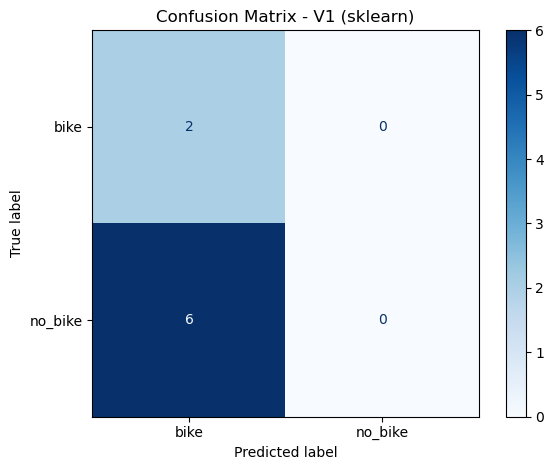

V1 → Accuracy: 0.25, Precision: [0.25 0.  ], Recall: [1. 0.]
TP=1, TN=0, FP=6, FN=0


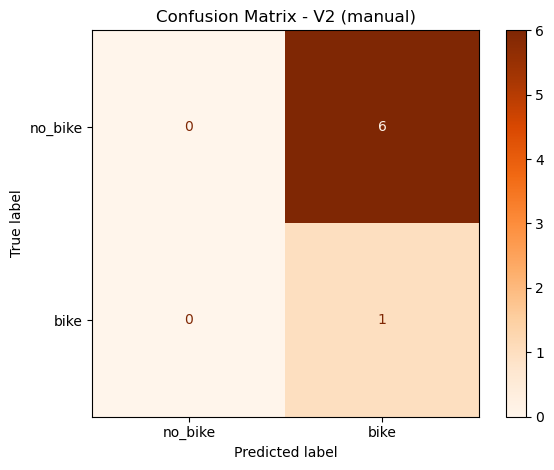

V2 → Accuracy: 0.14, Precision: 0.14, Recall: 1.00


In [26]:
ground_truth = {
    "data/test_images\\bike02.jpg": True,
    "data/test_images\\bike03.jpg": False,
    "data/test_images\\bike04.jpg": False,
    "data/test_images\\bike05.jpg": False,
    "data/test_images\\bike06.jpg": False,
    "data/test_images\\bike07.jpg": False,
    "data/test_images\\bike08.jpg": False,
    
}

eval_data = get_labels_for_evaluation(computer_vision_client(), "data/test_images", ground_truth)

real_labels, computed_labels, image_names = eval_data['v1_format']
labelNames = ['bike', 'no_bike']

acc, precision, recall = evalClassificationV11(real_labels, computed_labels, labelNames)
print(f"V1 → Accuracy: {acc:.2f}, Precision: {precision}, Recall: {recall}")


classification_results = eval_data['v2_format']
ground_truth = eval_data['ground_truth']

metrics = evalClassificationV22(classification_results, ground_truth)
print(f"V2 → Accuracy: {metrics['accuracy']:.2f}, Precision: {metrics['precision']:.2f}, Recall: {metrics['recall']:.2f}")

In [29]:
#second attempt 


In [41]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import glob
import os
import numpy as np

def hasBike(filepath):
    with open(filepath, "rb") as img:
        result = computer_vision_client().analyze_image_in_stream(
            img,
            visual_features=[VisualFeatureTypes.tags, VisualFeatureTypes.objects]
        )
    for ob in result.objects:
        if ob.object_property == "bicycle":
            return True
    return False

def getRealLabel(filepath):
    filename = os.path.basename(filepath).lower()
    return True if filename.startswith("bike") else False

def BikeAcc(realLabels, computedLabels):
    cm = confusion_matrix(realLabels, computedLabels)
    accuracy = accuracy_score(realLabels, computedLabels)
    precision = precision_score(realLabels, computedLabels)
    recall = recall_score(realLabels, computedLabels)
    return cm, accuracy, precision, recall

def myBikeAcc(realLabels, computedLabels):
    realLabels = np.array(realLabels, dtype=int)
    computedLabels = np.array(computedLabels, dtype=int)
    TP = ((realLabels == computedLabels) & (realLabels == 1)).sum()
    TN = ((realLabels == computedLabels) & (realLabels == 0)).sum()
    FP = ((realLabels != computedLabels) & (realLabels == 0)).sum()
    FN = ((realLabels != computedLabels) & (realLabels == 1)).sum()
    accuracy  = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
    recall_negative = TN / (TN + FN) if (TN + FN) > 0 else 0
    return accuracy, precision, recall, recall_negative

# --- Run analysis on all JPGs ---
all_files = sorted(glob.glob("data/test_images/*.jpg"))
real_labels = []
computed_labels = []

for file_path in all_files:
    real = getRealLabel(file_path)
    predicted = hasBike(file_path)
    print(f"{os.path.basename(file_path):30s}  real={real}  predicted={predicted}")
    real_labels.append(real)
    computed_labels.append(predicted)

# --- Metrics ---
cm, acc, prec, rec = BikeAcc(real_labels, computed_labels)
print("\nConfusion Matrix:\n", cm)
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")

acc2, prec2, rec2, rec_neg = myBikeAcc(real_labels, computed_labels)
print(f"\n[myBikeAcc] Accuracy={acc2:.3f}  Precision={prec2:.3f}  Recall={rec2:.3f}  Recall(neg)={rec_neg:.3f}")




bike02.jpg                      real=True  predicted=True
bike03.jpg                      real=True  predicted=True
bike04.jpg                      real=True  predicted=True
bike05.jpg                      real=True  predicted=True
bike06.jpg                      real=True  predicted=False
bike07.jpg                      real=True  predicted=True
bike08.jpg                      real=True  predicted=False
bike09.jpg                      real=True  predicted=True

Confusion Matrix:
 [[0 0]
 [2 6]]
Accuracy : 0.750
Precision: 1.000
Recall   : 0.750

[myBikeAcc] Accuracy=0.750  Precision=1.000  Recall=0.750  Recall(neg)=0.000


In [43]:
from PIL import Image, ImageDraw
import os

def drawBikes(filepath, output_dir="output"):
    os.makedirs(output_dir, exist_ok=True)

    with open(filepath, "rb") as img:
        result = computer_vision_client().analyze_image_in_stream(
            img,
            visual_features=[VisualFeatureTypes.tags, VisualFeatureTypes.objects]
        )

    image = Image.open(filepath).convert("RGB")
    draw = ImageDraw.Draw(image)

    found = False
    for ob in result.objects:
        if ob.object_property == "bicycle":
            found = True
            r = ob.rectangle
            draw.rectangle(
                [r.x, r.y, r.x + r.w, r.y + r.h],
                outline="red",
                width=3
            )

    if found:
        out_path = os.path.join(output_dir, os.path.basename(filepath))
        image.save(out_path)
        print(f"Saved with bounding box: {out_path}")
    else:
        print(f"No bicycle detected in: {os.path.basename(filepath)}")

# Run on all images
for file_path in all_files:
    if getRealLabel(file_path):  # only images that actually contain bikes
        drawBikes(file_path)

Saved with bounding box: output\bike02.jpg
Saved with bounding box: output\bike03.jpg
Saved with bounding box: output\bike04.jpg
Saved with bounding box: output\bike05.jpg
No bicycle detected in: bike06.jpg
Saved with bounding box: output\bike07.jpg
No bicycle detected in: bike08.jpg
Saved with bounding box: output\bike09.jpg


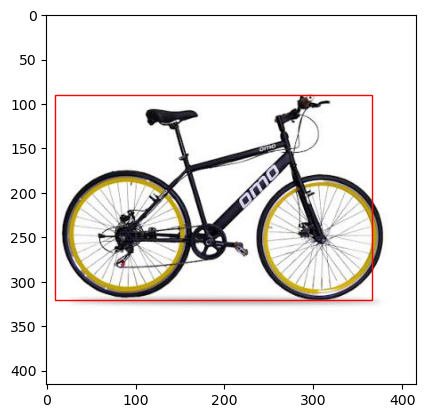

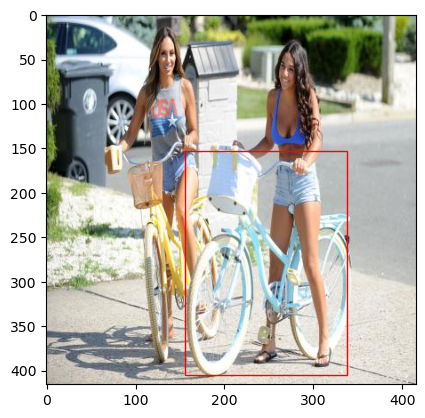

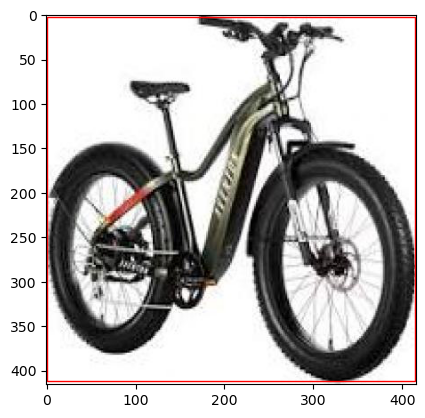

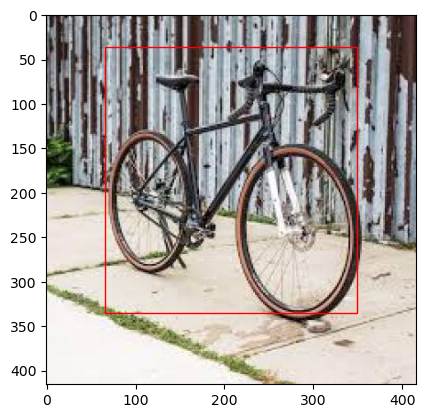

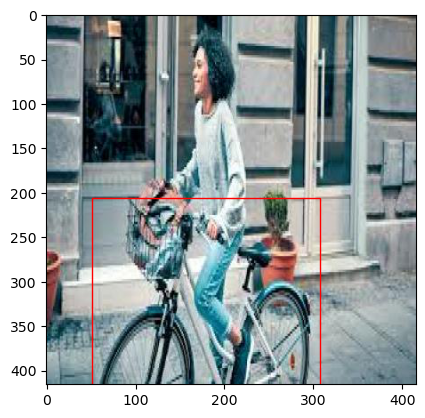

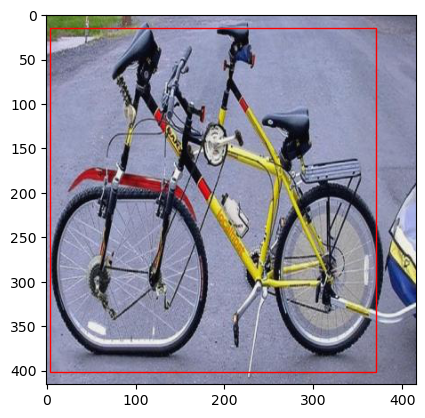

In [45]:
from matplotlib import pyplot as plt


def bikeCoords(filepath):
    img = open(filepath, "rb")
    result = computer_vision_client().analyze_image_in_stream(img, visual_features=[VisualFeatureTypes.tags, VisualFeatureTypes.objects])
    for ob in result.objects:
        if ob.object_property == "bicycle":
            return ob.rectangle
        
        
def hasBike(filepath):
    with open(filepath, "rb") as img:
        result = computer_vision_client().analyze_image_in_stream(
            img,
            visual_features=[VisualFeatureTypes.tags, VisualFeatureTypes.objects]
        )
    for ob in result.objects:
        if ob.object_property == "bicycle":
            return True
    return False

all_files = sorted(glob.glob("data/test_images/*.jpg"))
real_labels = []
computed_labels = []
true_coords=[[]]

for file_path in all_files:
    if(hasBike(file_path)):
        coordsToDraw = bikeCoords(file_path)
        im = plt.imread(file_path)
        fig= plt.imshow(im)
        fig.axes.add_patch(plt.Rectangle(xy=(coordsToDraw.x, coordsToDraw.y), width=coordsToDraw.w, height=coordsToDraw.h, fill=False, color="red"))
        plt.show()
        plt.show()

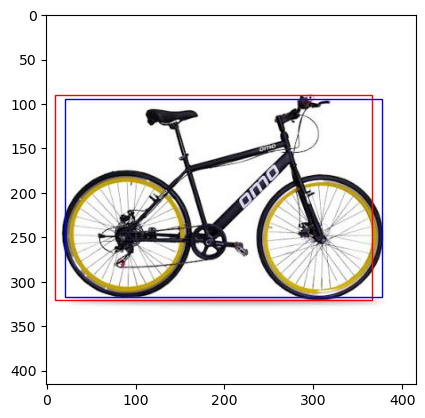

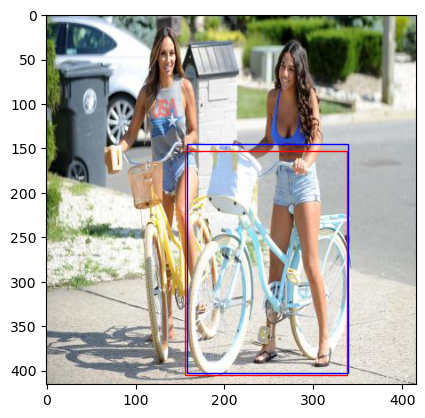

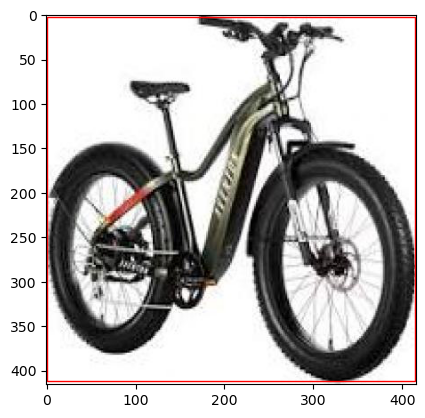

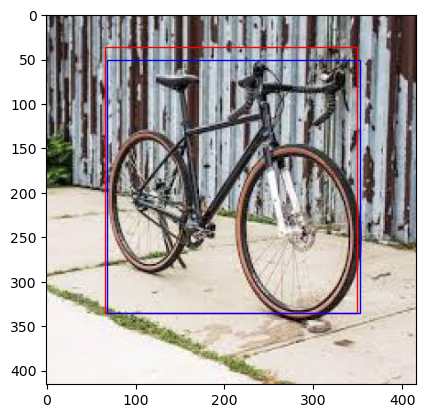

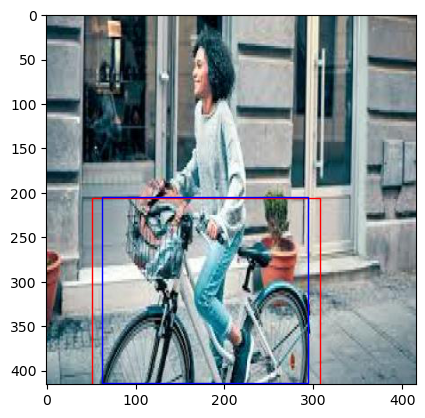

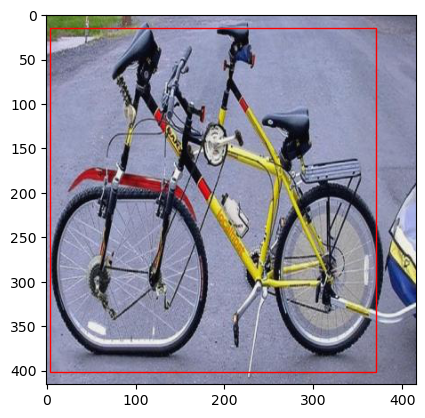

In [49]:
import glob
def bikeCoords(filepath):
    img = open(filepath, "rb")
    result = computer_vision_client().analyze_image_in_stream(img, visual_features=[VisualFeatureTypes.tags, VisualFeatureTypes.objects])
    for ob in result.objects:
        if ob.object_property == "bicycle":
            return ob.rectangle
def hasBike(filepath):
    with open(filepath, "rb") as img:
        result = computer_vision_client().analyze_image_in_stream(
            img,
            visual_features=[VisualFeatureTypes.tags, VisualFeatureTypes.objects]
        )
    for ob in result.objects:
        if ob.object_property == "bicycle":
            return True
    return False

all_files = sorted(glob.glob("data/test_images/*.jpg"))
real_labels = []
computed_labels = []
manual_annotations = {
    "data/test_images\\bike02.jpg": [(21, 94, 356, 223)],
     "data/test_images\\bike03.jpg": [(158, 145, 181, 258)],
     "data/test_images\\bike05.jpg": [(68, 50, 285, 285)],
     "data/test_images\\bike06.jpg": [(158, 145, 181, 258)],
     "data/test_images\\bike07.jpg": [(62, 205, 232, 209)],
     "data/test_images\\bike08.jpg": [(57, 2, 328, 351)],

}

for file_path in all_files:
    if(hasBike(file_path)):
        coordsToDraw = bikeCoords(file_path)
        im = plt.imread(file_path)
        fig= plt.imshow(im)
        fig.axes.add_patch(plt.Rectangle(xy=(coordsToDraw.x, coordsToDraw.y), width=coordsToDraw.w, height=coordsToDraw.h, fill=False, color="red"))
        if file_path in manual_annotations:
            for coords in manual_annotations[file_path]:
                fig.axes.add_patch(plt.Rectangle(xy=(coords[0], coords[1]), width=coords[2], height=coords[3], fill=False, color="blue"))

        plt.show()
        plt.show()

In [50]:
def compute_iou(boxA, boxB):
    """Both boxes in (x, y, w, h) format"""
    # Convert to (x1, y1, x2, y2)
    a = (boxA[0], boxA[1], boxA[0] + boxA[2], boxA[1] + boxA[3])
    b = (boxB[0], boxB[1], boxB[0] + boxB[2], boxB[1] + boxB[3])

    xA = max(a[0], b[0])
    yA = max(a[1], b[1])
    xB = min(a[2], b[2])
    yB = min(a[3], b[3])

    inter = max(0, xB - xA) * max(0, yB - yA)
    areaA = boxA[2] * boxA[3]
    areaB = boxB[2] * boxB[3]
    union = areaA + areaB - inter

    return inter / union if union > 0 else 0.0


def evaluate_detection(all_files, manual_annotations, iou_threshold=0.5):
    iou_scores = []
    detected = 0
    total = 0

    for file_path in all_files:
        # Only evaluate images that have manual annotations (i.e. confirmed bike images)
        if file_path not in manual_annotations:
            continue

        total += 1
        manual_boxes = manual_annotations[file_path]

        # Get Azure predicted box
        rect = bikeCoords(file_path)

        if rect is None:
            # Azure missed the bike entirely
            iou_scores.append(0.0)
            continue

        detected += 1
        predicted_box = (rect.x, rect.y, rect.w, rect.h)

        # Best IoU against all manual boxes for this image
        best_iou = max(compute_iou(predicted_box, mb) for mb in manual_boxes)
        iou_scores.append(best_iou)
        print(f"{file_path:45s}  IoU={best_iou:.3f}")

    # --- Metric 1: Mean IoU ---
    mean_iou = np.mean(iou_scores) if iou_scores else 0.0

    # --- Metric 2: Detection Rate at IoU threshold ---
    detection_rate = np.mean([s >= iou_threshold for s in iou_scores]) if iou_scores else 0.0

    print(f"\n=== Evaluation Results ===")
    print(f"Bike images evaluated : {total}")
    print(f"Detected by Azure     : {detected} / {total}")
    print(f"Mean IoU              : {mean_iou:.3f}")
    print(f"Detection Rate @{iou_threshold}   : {detection_rate:.3f}  ({sum(s >= iou_threshold for s in iou_scores)}/{total} boxes overlap well)")

    return mean_iou, detection_rate

evaluate_detection(all_files, manual_annotations)

data/test_images\bike02.jpg                    IoU=0.906
data/test_images\bike03.jpg                    IoU=0.941
data/test_images\bike05.jpg                    IoU=0.934
data/test_images\bike07.jpg                    IoU=0.890

=== Evaluation Results ===
Bike images evaluated : 6
Detected by Azure     : 4 / 6
Mean IoU              : 0.612
Detection Rate @0.5   : 0.667  (4/6 boxes overlap well)


(np.float64(0.6118793578318189), np.float64(0.6666666666666666))